In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 5)

df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (1407328, 6)

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 3 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [2]:
# Drop duplicate index column
df = df.drop(columns=['Unnamed: 0'])

# Basic stats
print("=== Dataset Info ===")
print(f"Total articles: {len(df):,}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Unique publishers: {df['publisher'].nunique():,}")
print(f"Unique stocks: {df['stock'].nunique():,}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nHeadline sample:\n{df['headline'].head(3).values}")

=== Dataset Info ===
Total articles: 1,407,328
Date range: 2009-02-14 00:00:00 → 2020-06-11 17:12:35-04:00
Unique publishers: 1,034
Unique stocks: 6,204

Missing values:
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

Headline sample:
<StringArray>
[   'Stocks That Hit 52-Week Highs On Friday',
 'Stocks That Hit 52-Week Highs On Wednesday',
              '71 Biggest Movers From Friday']
Length: 3, dtype: str


=== Headline Length Stats ===
       headline_length  word_count
count       1407328.00  1407328.00
mean             73.12       11.42
std              40.74        6.35
min               3.00        1.00
25%              47.00        7.00
50%              64.00       10.00
75%              87.00       13.00
max             512.00       77.00


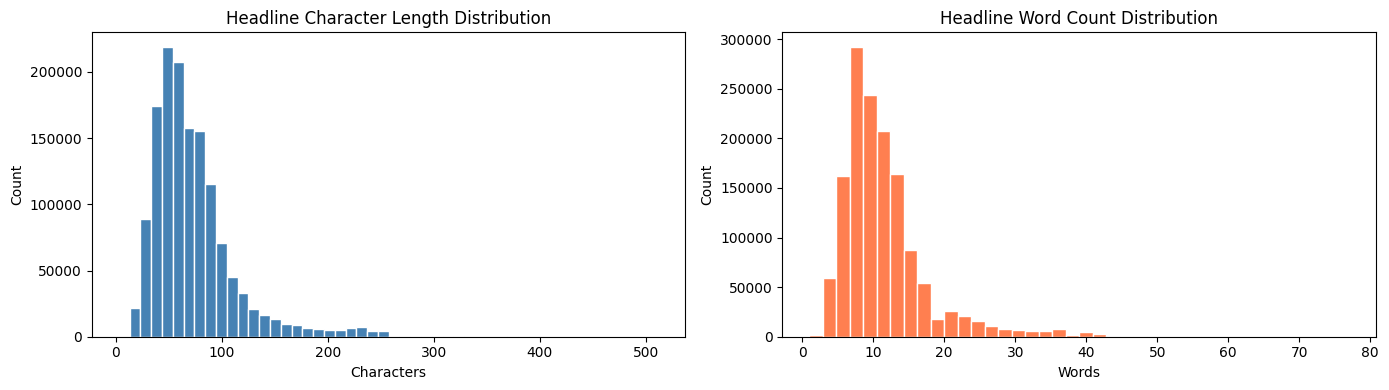

In [3]:
df['headline_length'] = df['headline'].str.len()
df['word_count'] = df['headline'].str.split().str.len()

print("=== Headline Length Stats ===")
print(df[['headline_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['headline_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Headline Character Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Headline Word Count Distribution')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/raw/headline_length.png', dpi=150)
plt.show()

=== Top 15 Publishers ===
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64


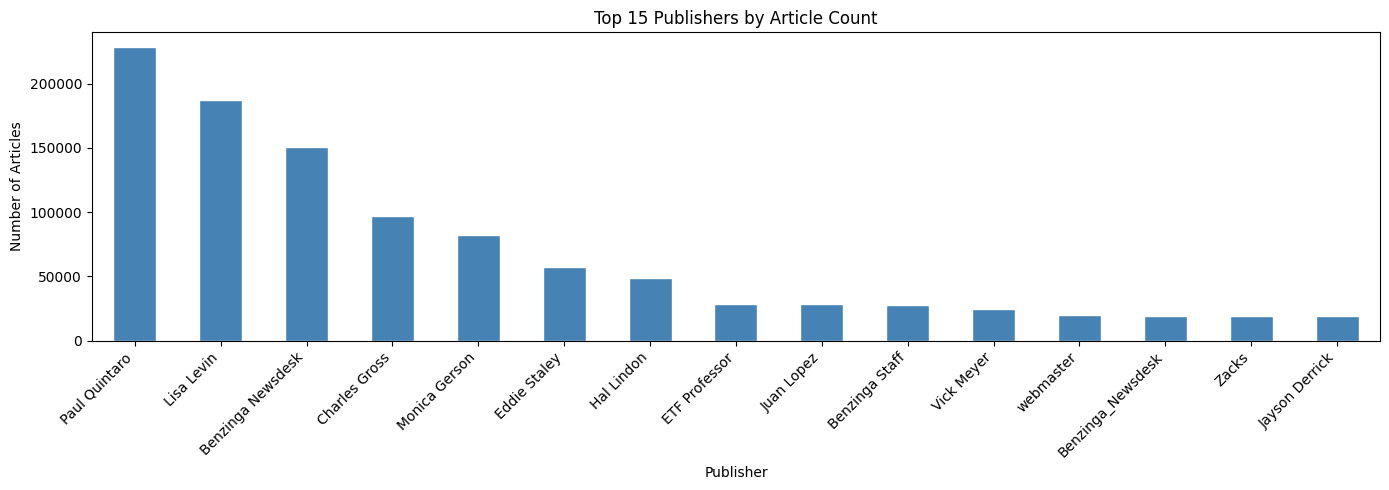


Email-format publishers: 18

Top domains:
domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


In [4]:
top_publishers = df['publisher'].value_counts().head(15)

print("=== Top 15 Publishers ===")
print(top_publishers)

plt.figure(figsize=(14, 5))
top_publishers.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Publishers by Article Count')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/raw/top_publishers.png', dpi=150)
plt.show()

# Check for email-format publishers
email_publishers = df[df['publisher'].str.contains('@', na=False)]
print(f"\nEmail-format publishers: {email_publishers['publisher'].nunique():,}")
if len(email_publishers) > 0:
    df['domain'] = df['publisher'].str.extract(r'@(.+)')
    print("\nTop domains:")
    print(df['domain'].value_counts().head(10))

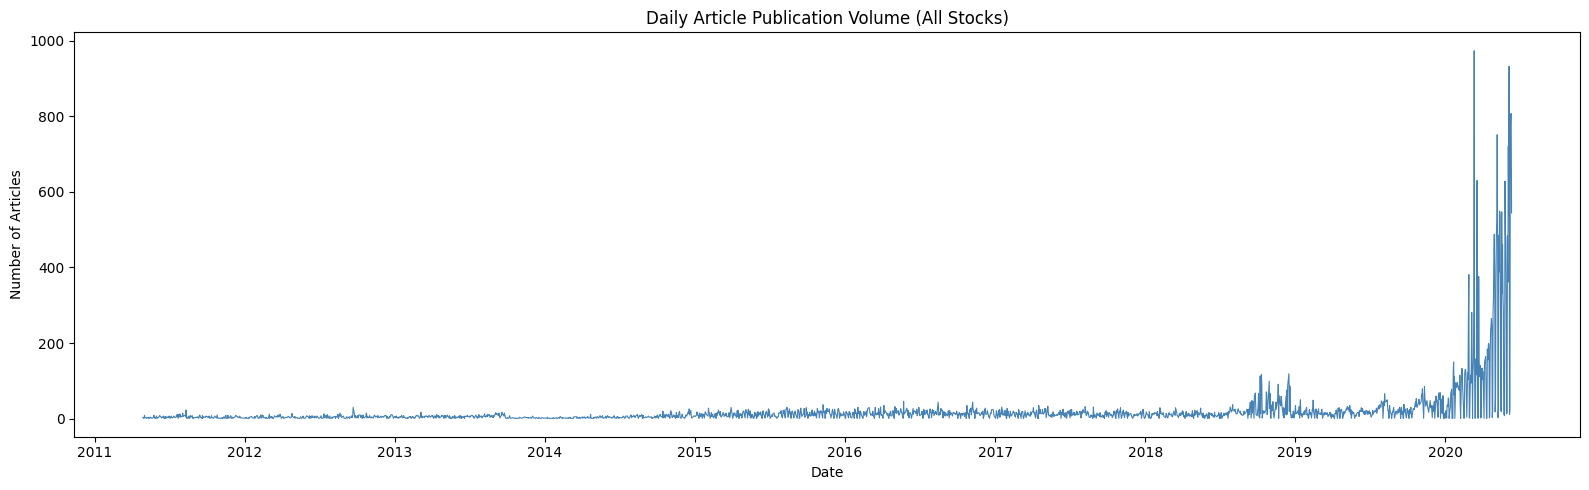

=== Top 10 Highest Volume Days ===
date_only
2020-03-12    973
2020-06-05    932
2020-06-10    807
2020-06-09    803
2020-06-08    765
2020-05-07    751
2020-06-03    720
2020-03-19    630
2020-05-26    628
2020-05-13    549
dtype: int64


In [5]:
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')
df['date_only'] = df['date'].dt.date

daily_counts = df.groupby('date_only').size()

plt.figure(figsize=(16, 5))
daily_counts.plot(color='steelblue', linewidth=0.8)
plt.title('Daily Article Publication Volume (All Stocks)')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.savefig('../data/raw/publication_timeseries.png', dpi=150)
plt.show()

print("=== Top 10 Highest Volume Days ===")
print(daily_counts.sort_values(ascending=False).head(10))

=== Top 25 Keywords/Phrases ===
vs            162099
stocks        161776
est           140604
eps           128897
market        120558
shares        114313
reports       108710
update         91723
earnings       87399
sales          79645
benzinga       74516
pt             73068
week           69572
announces      66591
price          64407
buy            64371
mid            62263
downgrades     61959
trading        61182
raises         57802
52             56972
upgrades       56811
target         54714
maintains      52961
52 week        51006
dtype: int64


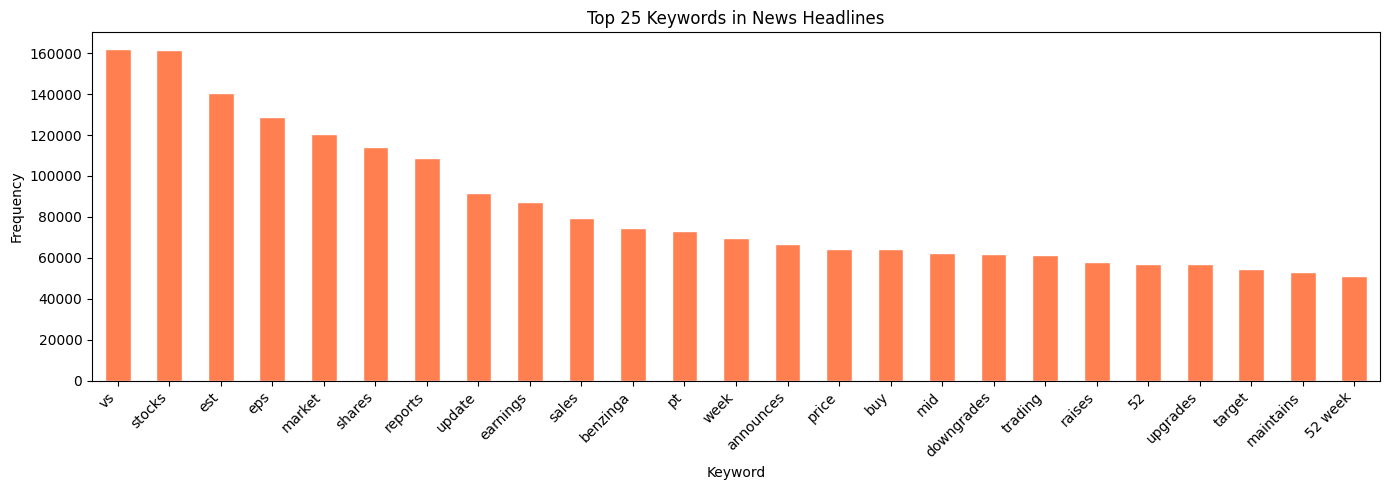

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words='english', max_features=25, ngram_range=(1,2))
X = vec.fit_transform(df['headline'].dropna())
word_freq = pd.Series(
    X.toarray().sum(axis=0),
    index=vec.get_feature_names_out()
).sort_values(ascending=False)

print("=== Top 25 Keywords/Phrases ===")
print(word_freq)

plt.figure(figsize=(14, 5))
word_freq.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 25 Keywords in News Headlines')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/raw/top_keywords.png', dpi=150)
plt.show()